# <b>Modelo de Previsão para Séries Temporais</b><br> <i>Custo com Água

## Componentes das Séries Temporais

 Uma série temporal pode ser decomposta em:
 - **Tendência:** direção de longo prazo
 - **Sazonalidade:** repetição periódica de padrões
 - **Ruído:** variação aleatória

### Importação das bibliotecas

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import statsmodels.tsa.stattools
import sys
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.statespace.sarimax import SARIMAX

### Importação de módulo com configurações para gráficos

In [2]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))

from src.scripts.plot_config import set_seaborn
set_seaborn()

### Carregamento e pré-visualização dos dados

In [3]:
df = pd.read_csv(
    "../../data/processed/processed_water.csv",
    usecols=["VALOR_FATURA", "DATA_VENCIMENTO"],
    index_col="DATA_VENCIMENTO",
    parse_dates=["DATA_VENCIMENTO"]
)

df = df.resample('ME').sum(numeric_only=True)
df.head(3)

,VALOR_FATURA
DATA_VENCIMENTO,
2022-02-28,2266691.11
2022-03-31,2243767.25
2022-04-30,2861797.77


### Visualização da Série Temporal

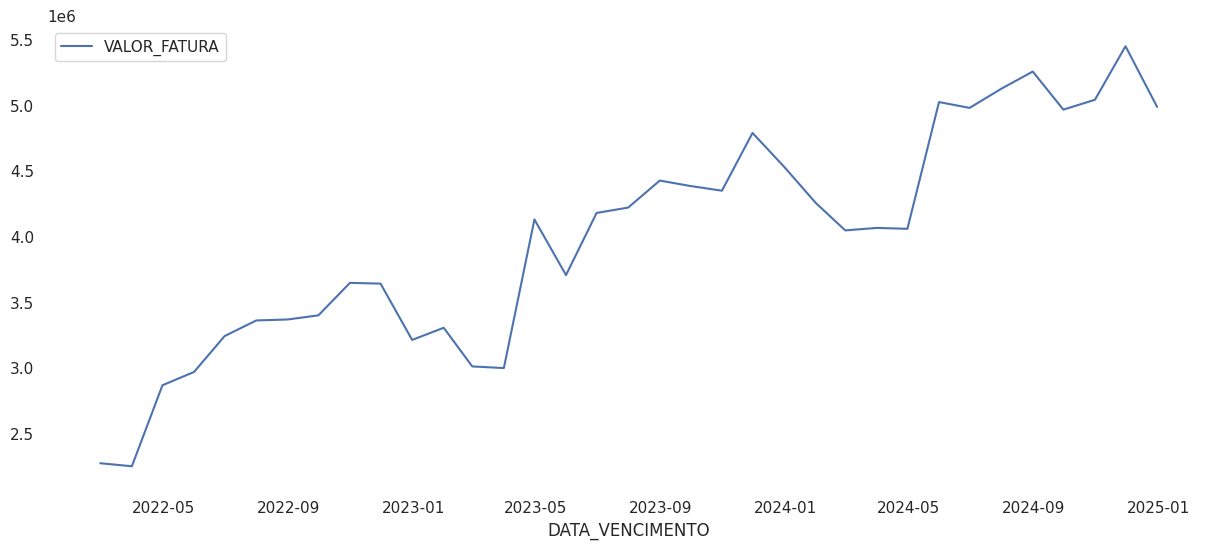

In [4]:
sns.lineplot(df);

### Teste de Normalidade dos Dados com QQ Plot e Shapiro-Wilk

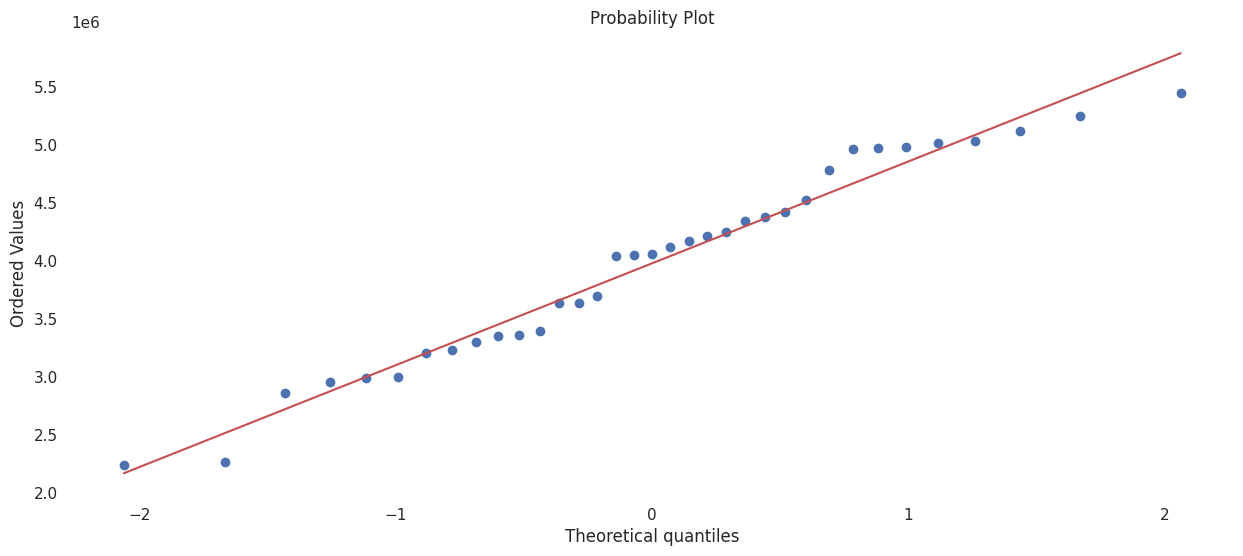

In [5]:
stats.probplot(df["VALOR_FATURA"], dist="norm", plot=plt)
plt.show()

Teste Shapiro-Wilk

CRITÉRIOS:<br>
NÍVEL DE SIGNIFICÂNCIA DE 0,05 ou 5% (MAIS UTILIZADO)

* H0: A série segue uma distribuição aproximadamente normal QUANDO p > 0,05.
* Ha: A série NÃO segue uma distribuição aproximadamente normal QUANDO p < 0,05.

In [6]:
e, p = stats.shapiro(df)
print('Estatística de teste: {}'.format(e))
print('p-valor: {}'.format(p))

Estatística de teste: 0.9643419620253055
p-valor: 0.30734068019894234


#### Transformação por log 

Diminui variância e melhora normalidade<br>
Aplica a função logarítmica em todos os dados da série

In [7]:
df_log = np.log(df)

e, p = stats.shapiro(df_log)
print('Estatística de teste: {}'.format(e))
print('p-valor: {}'.format(p))

Estatística de teste: 0.9439626013617578
p-valor: 0.07394581409790711


#### Transformação por raiz cúbica

Transformação muito utilizada quando a série possui dados com valor zero ou negativos

In [8]:
df_cube = np.sign(df)*abs(df)**(1/3)

e, p = stats.shapiro(df_cube)
print('Estatística de teste: {}'.format(e))
print('p-valor: {}'.format(p))

Estatística de teste: 0.9539924274876816
p-valor: 0.15025324174200883


#### Histograma para análise da distribuição entre série original e transformadas

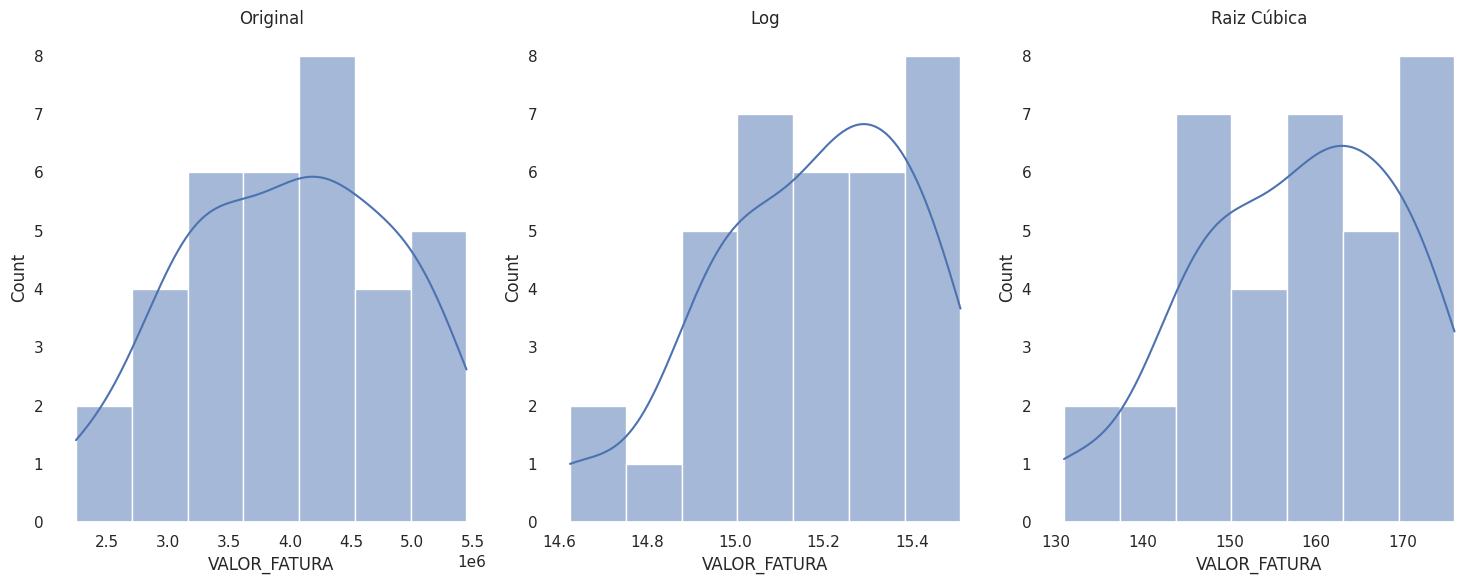

In [9]:
series = [df, df_log, df_cube]
titles = ["Original", "Log", "Raiz Cúbica"]

fig, axes = plt.subplots(1, 3)

for ax, data, title in zip(axes, series, titles):
    sns.histplot(data["VALOR_FATURA"], ax=ax, kde=True)
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Teste de Estacionaridade

***Teste de Dickey-Fuller Aumentado (ADF)*** O teste de Dickey-Fuller
Aumentado (ADF) é um teste de hipótese usado para verificar a
estacionaridade de uma série temporal.

-   **Hipótese Nula (H0)**: A série temporal tem uma raiz unitária (não
    estacionária).

-   **Hipótese Alternativa (H1)**: A série temporal é estacionária (sem
    raiz unitária).

-   **Rejeitar H0 (valor** $p$ \< 0.05): A série é estacionária.

-   **Não rejeitar H0 (valor** $p$ \> 0.05): A série não é estacionária
    (tem raiz unitária).

In [10]:
adf_result = statsmodels.tsa.stattools.adfuller(df, autolag='AIC')
print('ADF Test: Ruído Branco')
print('Estatística do teste: {:.4f}'.format(adf_result[0]))
print('p-valor: {:.4f}'.format(adf_result[1]))
print('Valores Críticos:')
for chave, valor in adf_result[4].items():
    print('{}: {:.4f}'.format(chave, valor))
print('Resultado:')
if adf_result[1] <= 0.05:
    print("Rejeitar a hipótese nula (H0): Os dados são estacionários.")
else:
    print("Falha ao rejeitar a hipótese nula (H0): Os dados não são estacionários.")
print('\n')

ADF Test: Ruído Branco
Estatística do teste: -1.8292
p-valor: 0.3661
Valores Críticos:
1%: -3.6392
5%: -2.9512
10%: -2.6144
Resultado:
Falha ao rejeitar a hipótese nula (H0): Os dados não são estacionários.




#### Teste KPSS (Kwiatkowski-Phillips-Schmidt-Shin)

O teste KPSS é usado para verificar a estacionaridade de uma série
temporal, mas ao contrário do teste ADF, sua hipótese nula é que a série
é estacionária.

##### Hipóteses:

-   **Hipótese Nula (H0)**: A série temporal é estacionária.

-   **Hipótese Alternativa (H1)**: A série temporal não é estacionária.

-   **Rejeitar H0 (valor KPSS grande )**: A série não é estacionária.

-   **Não rejeitar H0 (valor KPSS pequeno)**: A série é estacionária.

In [11]:
kpss_result = statsmodels.tsa.stattools.kpss(df, regression='c')
print('KPSS Test: Ruído Branco')
print('Estatística do teste: {:.4f}'.format(kpss_result[0]))
print('p-valor: {:.4f}'.format(kpss_result[1]))
print('Valores Críticos:')
for chave, valor in kpss_result[3].items():
    print('{}: {:.4f}'.format(chave, valor))
print('Resultado:')
if kpss_result[1] <= 0.05:
    print("Rejeitar a hipótese nula (H0): Os dados não são estacionários.")
else:
    print("Falha ao rejeitar a hipótese nula (H0): Os dados são estacionários.")
print('\n')

KPSS Test: Ruído Branco
Estatística do teste: 0.9108
p-valor: 0.0100
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390
Resultado:
Rejeitar a hipótese nula (H0): Os dados não são estacionários.




/tmp/ipykernel_15125/2765764661.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = statsmodels.tsa.stattools.kpss(df, regression='c')


### Eliminação do ruído (suavização) com média movel para análise de tendência

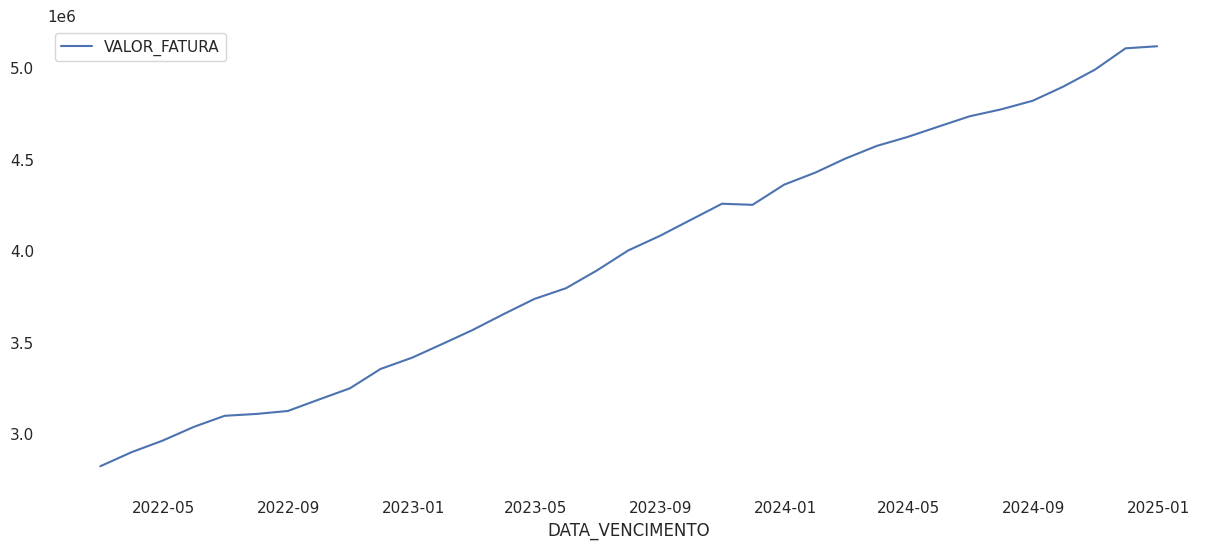

In [12]:
tendencia = df.rolling(window=12, center=True, min_periods=1).mean()
sns.lineplot(tendencia);

### Remoção da tendência com diferenciação para tornar a série estacionária
<code>diff(1)</code> subtrai o valor anterior do atual, ou seja:
$$
y_t' = y_t - y_{t-1}
$$

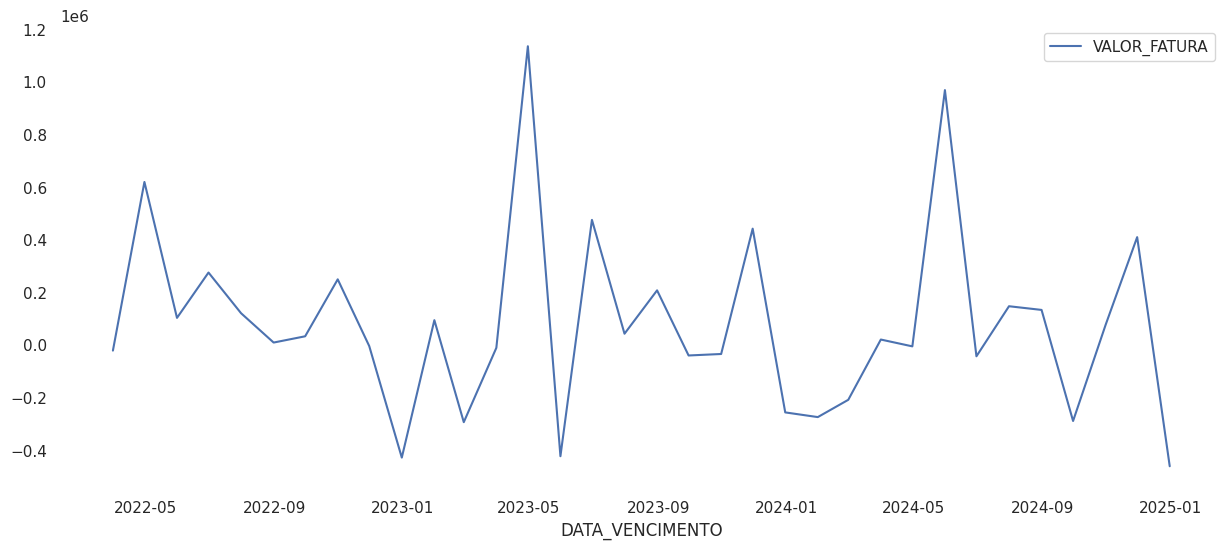

In [13]:
diferenca = df.diff(1)
sns.lineplot(diferenca);

In [14]:
diferenca_1 = df.diff(1).dropna()

adf_result = statsmodels.tsa.stattools.adfuller(diferenca_1, autolag='AIC')
print('ADF Test: Ruído Branco')
print('Estatística do teste: {:.4f}'.format(adf_result[0]))
print('p-valor: {:.4f}'.format(adf_result[1]))
print('Valores Críticos:')
for chave, valor in adf_result[4].items():
    print('{}: {:.4f}'.format(chave, valor))
print('Resultado:')
if adf_result[1] <= 0.05:
    print("Rejeitar a hipótese nula (H0): Os dados são estacionários.")
else:
    print("Falha ao rejeitar a hipótese nula (H0): Os dados não são estacionários.")
print('\n')

ADF Test: Ruído Branco
Estatística do teste: -3.5235
p-valor: 0.0074
Valores Críticos:
1%: -3.7529
5%: -2.9985
10%: -2.6390
Resultado:
Rejeitar a hipótese nula (H0): Os dados são estacionários.




In [15]:
diferenca_2 = diferenca_1.diff(1).dropna()

adf_result = statsmodels.tsa.stattools.adfuller(diferenca_2, autolag='AIC')
print('ADF Test: Ruído Branco')
print('Estatística do teste: {:.4f}'.format(adf_result[0]))
print('p-valor: {:.4f}'.format(adf_result[1]))
print('Valores Críticos:')
for chave, valor in adf_result[4].items():
    print('{}: {:.4f}'.format(chave, valor))
print('Resultado:')
if adf_result[1] <= 0.05:
    print("Rejeitar a hipótese nula (H0): Os dados são estacionários.")
else:
    print("Falha ao rejeitar a hipótese nula (H0): Os dados não são estacionários.")
print('\n')

ADF Test: Ruído Branco
Estatística do teste: -7.6141
p-valor: 0.0000
Valores Críticos:
1%: -3.6614
5%: -2.9605
10%: -2.6193
Resultado:
Rejeitar a hipótese nula (H0): Os dados são estacionários.




### Isolamento da sazonalidade para identificar padrões periódicos recorrentes na série

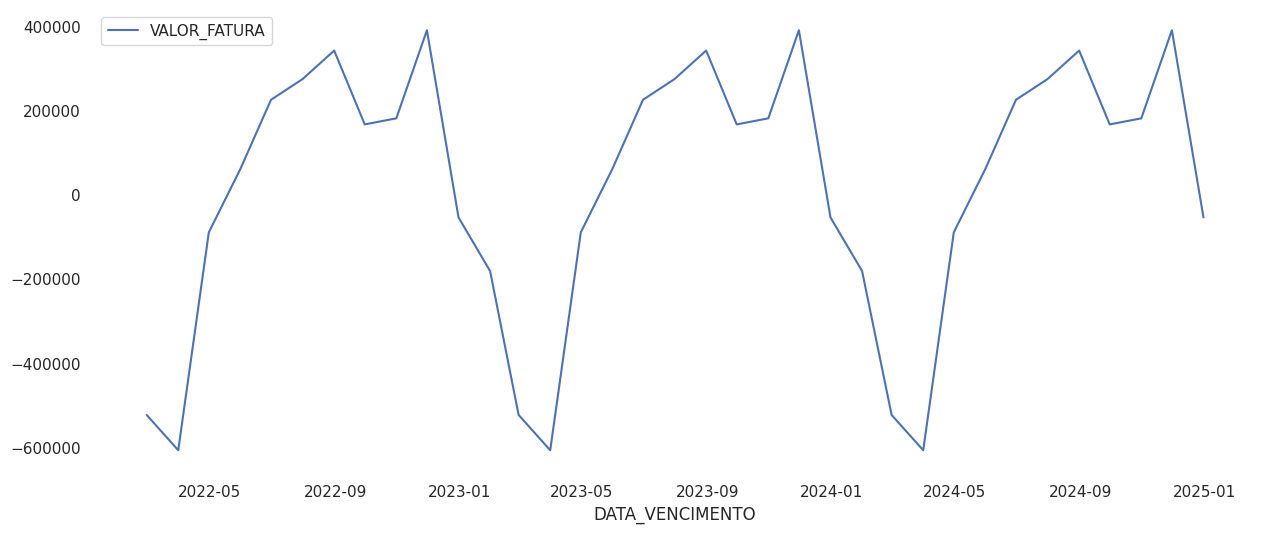

In [16]:
season_index = df.index.month
sazonalidade = (df - tendencia).groupby(season_index).transform('mean')
sns.lineplot(sazonalidade);

### Isolamento do ruído (resíduo): parte aleatória da série após remoção da tendência e da sazonalidade

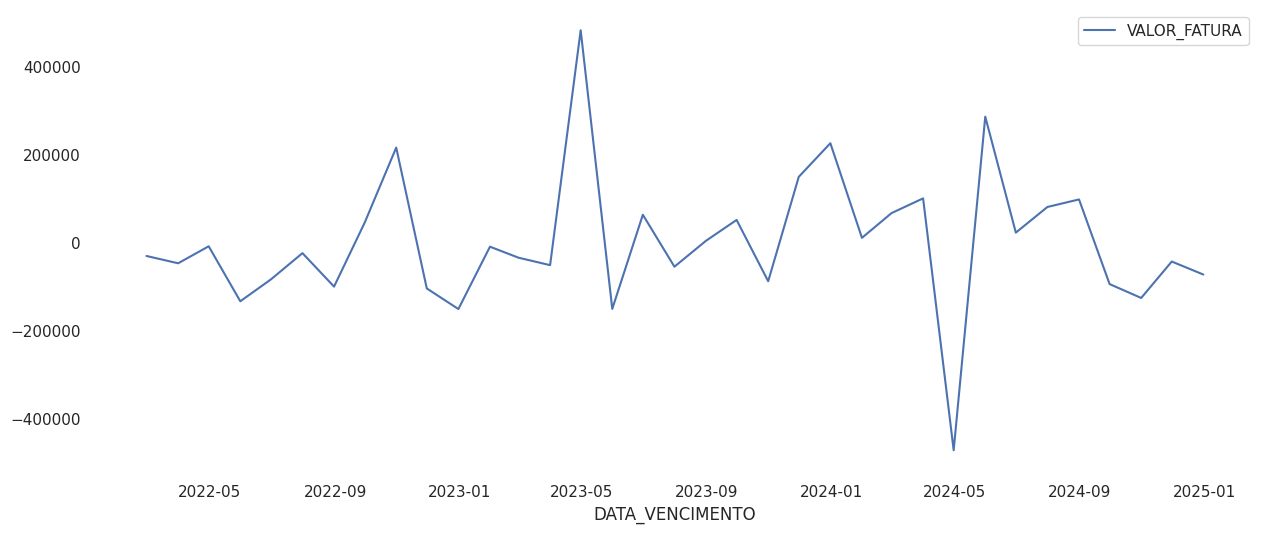

In [17]:
ruido = df - tendencia - sazonalidade
sns.lineplot(ruido);

### Correlograma

AR (AutoRegressivo) → use o PACF para identificar p;<br>
MA (Média Móvel) → use o ACF para identificar q.

Interpretação prática:

Se o ACF corta abruptamente após alguns lags → o modelo pode ter um componente MA(q).<br>
Se o ACF decai lentamente → a série pode precisar de diferenciação (d) para se tornar estacionária.

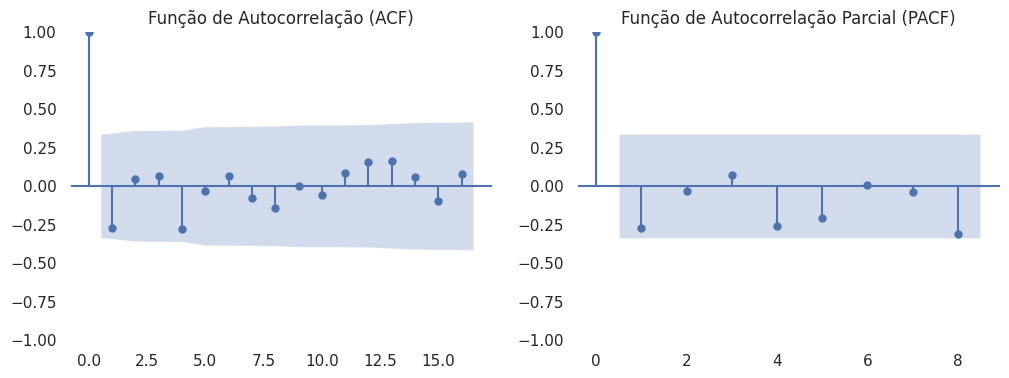

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
plot_acf(diferenca_1, lags=16, ax=axes[0])
plot_pacf(diferenca_1, lags=8, ax=axes[1])
axes[0].set_title('Função de Autocorrelação (ACF)')
axes[1].set_title('Função de Autocorrelação Parcial (PACF)')
plt.show()

### Teste de independência:

H₀ (nula) → os dados são independentes (ruído branco).<br>
H₁ (alternativa) → há autocorrelação (ainda há estrutura a modelar).

Se o p-valor > 0.05 → não rejeita H₀, ou seja, parece ruído branco (bom sinal para resíduos).
Se o p-valor ≤ 0.05 → rejeita H₀, há correlação restante (modelo ainda pode ser melhorado).

In [19]:
lb = acorr_ljungbox(diferenca_1, lags=[6, 12, 18, 24], return_df=True)
print("Ljung-Box (p-values):")
print(lb[['lb_stat','lb_pvalue']])

Ljung-Box (p-values):
      lb_stat  lb_pvalue
6    6.441748   0.375564
12   9.569036   0.653711
18  15.488608   0.628190
24  25.704192   0.368343


### Modelos candidatos com ARIMA

Quanto menor o AIC, melhor é o modelo

In [20]:
for order in [(0,1,0), (1,1,0), (0,1,1), (1,1,1)]:
    model = ARIMA(diferenca_1, order=order).fit()
    resid = model.resid.dropna()
    ljb = acorr_ljungbox(resid, lags=[6, 12, 18, 24], return_df=True)
    print(order, 'AIC:', model.aic)
    print(ljb[['lb_stat','lb_pvalue']], "\n")

(0, 1, 0) AIC: 969.1452652660776
      lb_stat  lb_pvalue
6   16.422304   0.011658
12  18.107446   0.112467
18  23.863247   0.159559
24  34.329135   0.078987 

(1, 1, 0) AIC: 955.424333121124
      lb_stat  lb_pvalue
6   12.790360   0.046489
12  15.017595   0.240476
18  23.245318   0.181338
24  38.794726   0.028694 

(0, 1, 1) AIC: 946.7303000569644
      lb_stat  lb_pvalue
6    6.190662   0.402175
12   9.981519   0.617582
18  15.701852   0.613346
24  25.671755   0.370028 

(1, 1, 1) AIC: 946.0150288225906
      lb_stat  lb_pvalue
6    4.896418   0.557165
12  11.997239   0.445901
18  20.304564   0.315937
24  28.763497   0.229159 



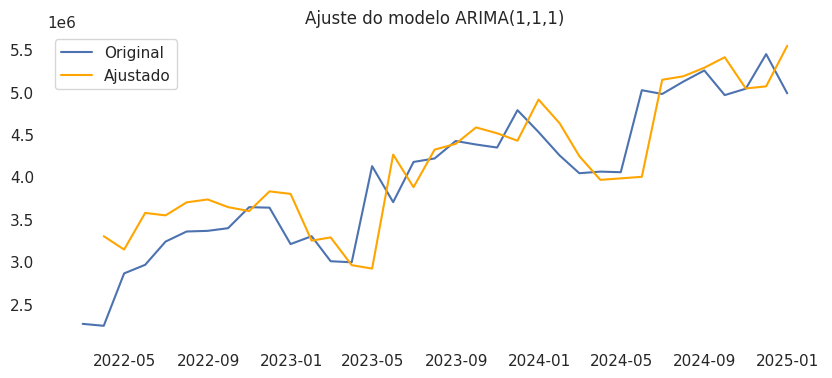

In [21]:
melhor_modelo = ARIMA(df, order=(1,2,1)).fit()
pred = melhor_modelo.predict(start=df.index[1], end=df.index[-1], typ='levels')
plt.figure(figsize=(10,4))
plt.plot(df, label='Original')
plt.plot(pred, label='Ajustado', color='orange')
plt.title('Ajuste do modelo ARIMA(1,1,1)')
plt.legend()
plt.show()

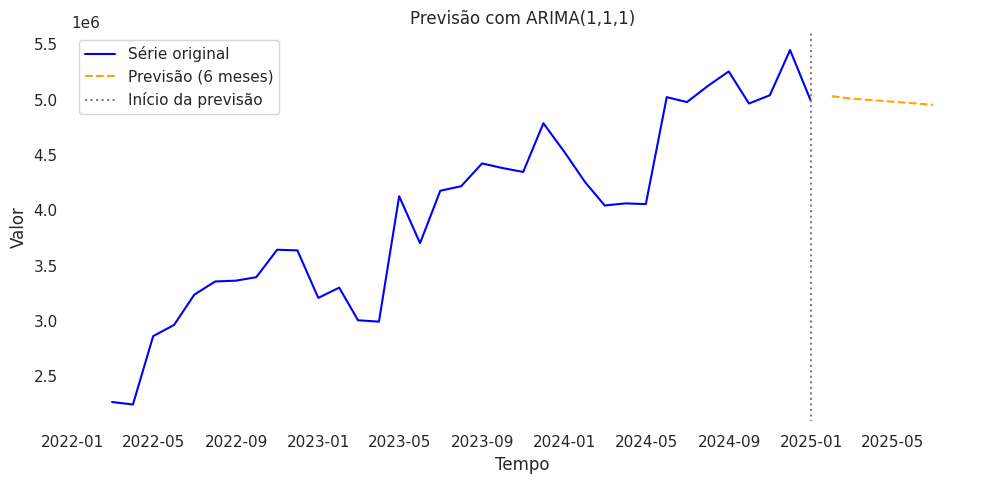

In [22]:
forecast = melhor_modelo.forecast(steps=6)
forecast_index = pd.date_range(start=df.index[-1] + pd.offsets.MonthEnd(1),
                               periods=6, freq='ME')
forecast_series = pd.Series(forecast, index=forecast_index)

plt.figure(figsize=(10,5))
plt.plot(df, label='Série original', color='blue')
plt.plot(forecast_series, label='Previsão (6 meses)', color='orange', linestyle='--')
plt.axvline(x=df.index[-1], color='gray', linestyle=':', label='Início da previsão')
plt.title('Previsão com ARIMA(1,1,1)')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Modelo SARIMA para sazonalidade

In [23]:
sarima_model = SARIMAX(df,
                       order=(1,1,1),
                       seasonal_order=(1,1,1,12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

/home/red/Projects/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                       VALOR_FATURA   No. Observations:                   35
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -109.738
Date:                            Sat, 01 Nov 2025   AIC                            229.476
Time:                                    21:27:21   BIC                            229.873
Sample:                                02-28-2022   HQIC                           226.797
                                     - 12-31-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2732      3.715     -0.074      0.941      -7.555       7.008
ma.L1         -0.7359      2.109   

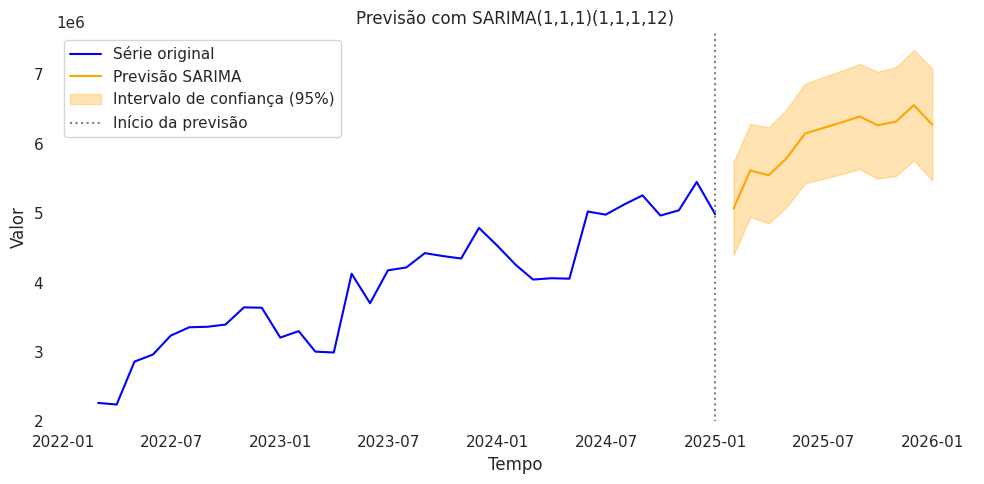

In [24]:
n_forecast = 12
forecast_res = sarima_fit.get_forecast(steps=n_forecast)

forecast_mean = forecast_res.predicted_mean
forecast_ci = forecast_res.conf_int()

forecast_index = pd.date_range(start=df.index[-1] + pd.offsets.MonthEnd(1),
                               periods=n_forecast, freq='ME')
forecast_mean.index = forecast_index
forecast_ci.index = forecast_index

plt.figure(figsize=(10,5))
plt.plot(df, label='Série original', color='blue')

plt.plot(forecast_mean, label='Previsão SARIMA', color='orange')

plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:,0],
                 forecast_ci.iloc[:,1],
                 color='orange', alpha=0.3, label='Intervalo de confiança (95%)')

plt.axvline(x=df.index[-1], color='gray', linestyle=':', label='Início da previsão')

plt.title('Previsão com SARIMA(1,1,1)(1,1,1,12)')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### REVERSÃO DA TRANSFORMAÇÃO E DIFERENCIAÇÃO

Ao realizarmos a transformação e diferenciação das séries temporais<br>
alteramos os valores das séries, logo para fazermos previsões<br>
temos que realizar a reversão da trasnformação e diferenciação das séries<br>

Reversão da transformação por logatitimo natural de base e

In [25]:
df_log_revertida =  np.e**df_log
df_log_revertida.head(3)

,VALOR_FATURA
DATA_VENCIMENTO,
2022-02-28,2266691.11
2022-03-31,2243767.25
2022-04-30,2861797.77


Reversão da transformação por raiz cúbica (quando possui dados com valor zero ou negativos)

In [26]:
df_cube_revertida = df_cube**3
df_cube_revertida.head(3)

,VALOR_FATURA
DATA_VENCIMENTO,
2022-02-28,2266691.11
2022-03-31,2243767.25
2022-04-30,2861797.77


### REVERSÃO DA DIFERENCIAÇÃO

Lembrando que iremos perder o primeiro valor pois não temos o antecessor para subtrair

In [27]:
diferenca_revertida = df.shift(1) + diferenca
diferenca_revertida.head(4)

,VALOR_FATURA
DATA_VENCIMENTO,
2022-02-28,NaN
2022-03-31,2243767.25
2022-04-30,2861797.77
2022-05-31,2963227.93


In [28]:
diferenca_2_revertida = df.shift(1) + diferenca_1
diferenca_2_revertida = diferenca_2_revertida.shift(1) + diferenca_1
diferenca_2_revertida.head(4)

,VALOR_FATURA
DATA_VENCIMENTO,
2022-02-28,NaN
2022-03-31,NaN
2022-04-30,2861797.77
2022-05-31,2963227.93
